<!-- HTML file automatically generated from DocOnce source (https://github.com/doconce/doconce/)
doconce format html hw7.do.txt --no_mako -->
<!-- dom:TITLE: PHY321: Classical Mechanics 1 -->

# PHY321: Classical Mechanics 1
**Homework 7, due Monday  March 27**

Date: **Mar 12, 2023**

# Siddak and Agrim

### Practicalities about  homeworks and projects

1. You can work in groups (optimal groups are often 2-3 people) or by yourself. If you work as a group you can hand in one answer only if you wish. **Remember to write your name(s)**!

2. Homeworks are available  the week before the deadline. 

3. How do I(we)  hand in?  Due to the corona virus and many of you not being on campus, we recommend that you scan your handwritten notes and upload them to D2L. If you are ok with typing mathematical formulae using say Latex, you can hand in everything as a single jupyter notebook at D2L. The numerical exercise(s) should always be handed in as a jupyter notebook by the deadline at D2L.

### Introduction to homework 7

In this week's homework we will apply our insights about harmonic
oscillations. The relevant material to survey is chapter 5 of Taylor.
See also the slides from [week 11](https://mhjensen.github.io/Physics321/doc/pub/week10/html/week10.html).

We have also added an exercise (exercise 2) related to our discussion of two-body problems. 
The relevant reading background for exercise 2 is given by sections 8.1-8.2 of Taylor.

### Exercise 1 (80 pts), the mathematical pendulum

Relevant reading here is Taylor chapter 5 and the lecture notes on oscillations from [week 11](https://mhjensen.github.io/Physics321/doc/pub/week10/html/week10.html).

The angular equation of motion of the pendulum is given by
Newton's equation and with no external force it reads

<!-- Equation labels as ordinary links -->
<div id="_auto1"></div>

$$
\begin{equation}
  ml\frac{d^2\theta}{dt^2}+mgsin(\theta)=0,
\label{_auto1} \tag{1}
\end{equation}
$$

with an angular velocity and acceleration given by

<!-- Equation labels as ordinary links -->
<div id="_auto2"></div>

$$
\begin{equation}
     v=l\frac{d\theta}{dt},
\label{_auto2} \tag{2}
\end{equation}
$$

and

<!-- Equation labels as ordinary links -->
<div id="_auto3"></div>

$$
\begin{equation}
     a=l\frac{d^2\theta}{dt^2}.
\label{_auto3} \tag{3}
\end{equation}
$$

We do however expect that the motion will gradually come to an end
due a viscous drag torque acting on the pendulum. 
In the presence of the drag, the above equation becomes

<!-- Equation labels as ordinary links -->
<div id="eq:pend1"></div>

$$
\begin{equation}
   ml\frac{d^2\theta}{dt^2}+\nu\frac{d\theta}{dt}  +mgsin(\theta)=0,
\label{eq:pend1} \tag{4}
\end{equation}
$$

where $\nu$ is now a positive constant parameterizing the viscosity
of the medium in question. In order to maintain the motion against
viscosity, it is necessary to add some external driving force. 
We choose here a periodic driving force. The last equation becomes then

<!-- Equation labels as ordinary links -->
<div id="eq:pend2"></div>

$$
\begin{equation}
   ml\frac{d^2\theta}{dt^2}+\nu\frac{d\theta}{dt}  +mgsin(\theta)=Asin(\omega t),
\label{eq:pend2} \tag{5}
\end{equation}
$$

with $A$ and $\omega$ two constants representing the amplitude and 
the angular frequency respectively. The latter is called the driving frequency.

* 1a (10pts)

Rewrite Eqs. ([4](#eq:pend1)) and ([5](#eq:pend2)) as dimensionless
equations in time. 


* 1b (40pts)

Write then a code which solves Eq. ([4](#eq:pend1)) using the
Euler-Cromer method or for example the fourth-order Runge Kutta method. Perform
calculations for at least ten periods with $N=100$, $N=1000$ and
$N=10000$ integration points/discretization points in time (such points are often called mesh points) and values of $\nu = 1$, $\nu = 5$ and $\nu
=10$.  Set $l=1.0$ m, $g=1$ m/s$^2$ and $m=1$ kg.  Choose as initial
conditions $\theta(0) = 0.2$ (radians) and $v(0) = 0$ (radians/s).
Make plots of $\theta$ (in radians) as function of time and phase
space plots of $\theta$ versus the velocity $v$.  Check the stability
of your results as functions of time and number of discretization/mesh points.  Which
case corresponds to damped, underdamped and overdamped oscillatory
motion?  Comment your results.

* 1c (30pts) 

Now we switch to Eq. ([5](#eq:pend2)) for the rest of the exercise. Add
an external driving force and set $l=g=1$, $m=1$, $\nu = 1/2$ and
$\omega = 2/3$.  Choose as initial conditions $\theta(0) = 0.2$ and
$v(0) = 0$ and $A=0.5$ and $A=1.2$.  Make plots of $\theta$ (in
radians) as function of time for at least 300 periods and phase space
plots of $\theta$ versus the velocity $v$. Choose an appropriate time
step. Comment and explain the results for the different values of $A$.

* 1d **optional exercise** (20pts bonus) 

Keep now the constants from the previous exercise fixed but
set now $A=1.35$, $A=1.44$ and $A=1.465$. Plot $\theta$ (in radians)
as function of time for at least 300 periods for these values of $A$
and comment your results.

* 1e **optional exercise** (20pts bonus)

We want to analyse further these results by making phase space plots
of $\theta$ versus the velocity $v$ using only the points where we
have $\omega t=2n\pi$ where $n$ is an integer. These are normally
called the drive periods.  This is an example of what is called a
Poincare section and is a very useful way to plot and analyze the
behavior of a dynamical system. Comment your results.

# 1b)

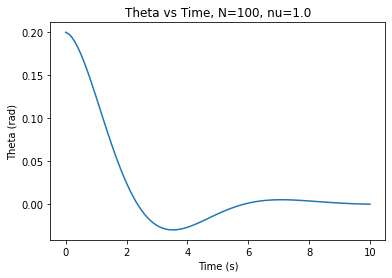

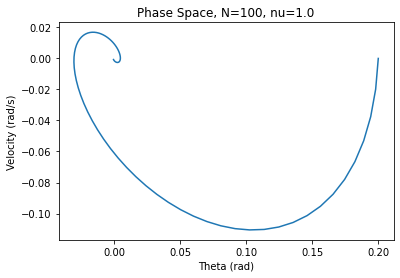

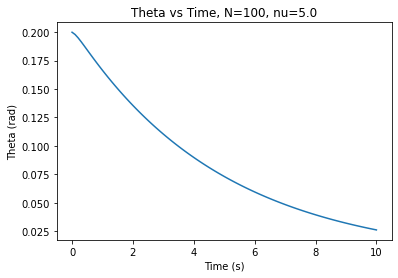

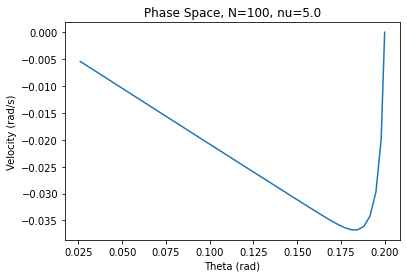

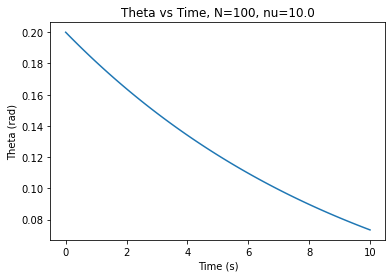

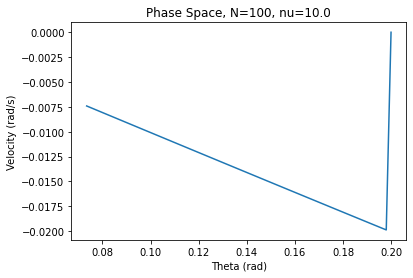

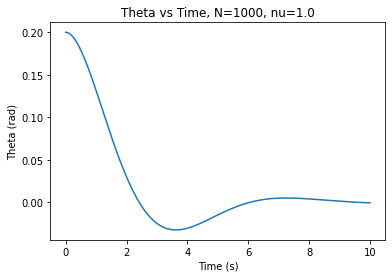

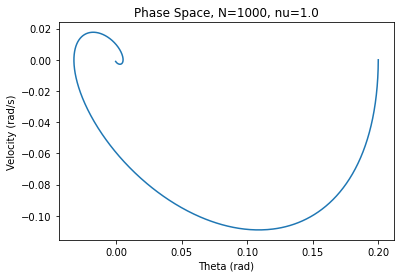

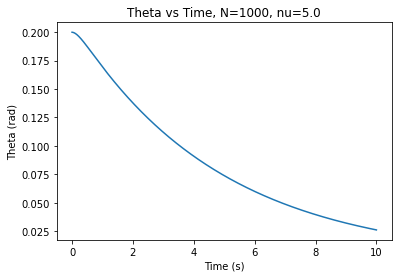

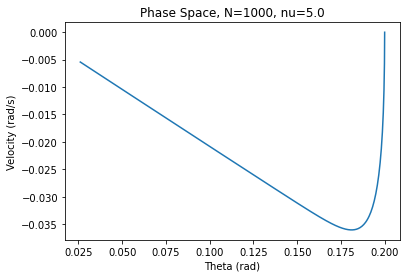

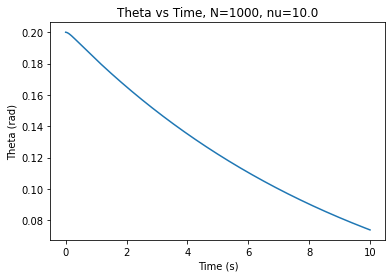

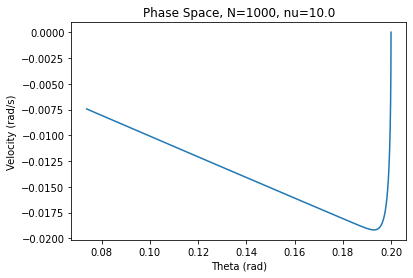

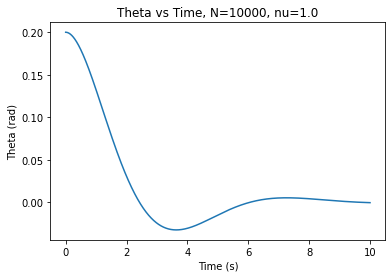

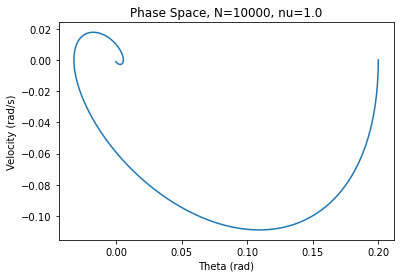

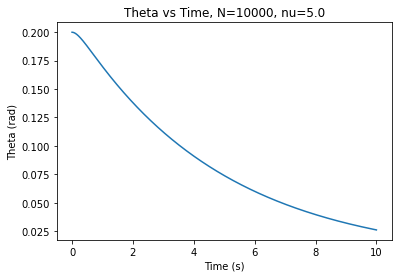

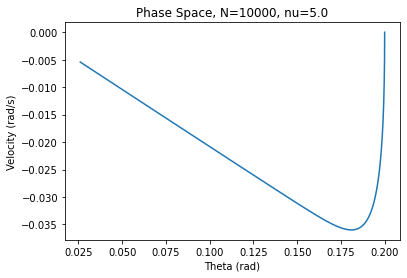

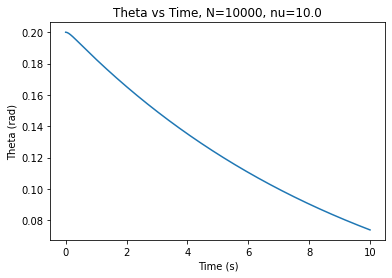

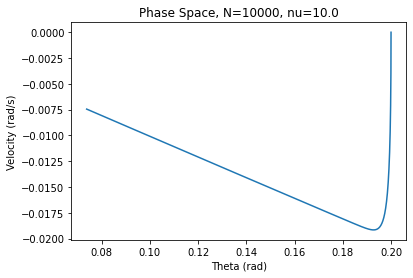

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Constants
m = 1.0
g = 1.0
l = 1.0

# Initial conditions
theta0 = 0.2
v0 = 0.0

# Time and mesh points
T = 10.0
N_list = [100, 1000, 10000]

# Viscosity values
nu_list = [1.0, 5.0, 10.0]

# Function for the RHS of the ODE
def f(theta, v, nu):
    return -g/l*np.sin(theta) - nu/(m*l**2)*v

# Euler-Cromer method
def euler_cromer(theta0, v0, nu, N, T):
    h = T/N
    t = np.linspace(0, T, N+1)
    theta = np.zeros(N+1)
    v = np.zeros(N+1)
    theta[0] = theta0
    v[0] = v0
    
    for i in range(N):
        v[i+1] = v[i] + h*f(theta[i], v[i], nu)
        theta[i+1] = theta[i] + h*v[i+1]
        
    return t, theta, v

# Perform calculations for different N and nu values
for N in N_list:
    for nu in nu_list:
        t, theta, v = euler_cromer(theta0, v0, nu, N, T)
        
        # Plot theta vs time
        plt.figure()
        plt.plot(t, theta)
        plt.xlabel('Time (s)')
        plt.ylabel('Theta (rad)')
        plt.title(f'Theta vs Time, N={N}, nu={nu}')
        
        # Plot theta vs v
        plt.figure()
        plt.plot(theta, v)
        plt.xlabel('Theta (rad)')
        plt.ylabel('Velocity (rad/s)')
        plt.title(f'Phase Space, N={N}, nu={nu}')
        
plt.show()


We can see that for low values of nu (nu=1), the motion is oscillatory but with decreasing amplitude due to the damping effect. This corresponds to underdamped motion. As we increase the value of nu (nu=5), the motion becomes critically damped as we can see the amplitude approaches at a faster rate. Finally, for even higher values of nu (nu=10), the motion becomes overdamped, where it approaches zero at a slower rate and in more amount of time.

# 1c)

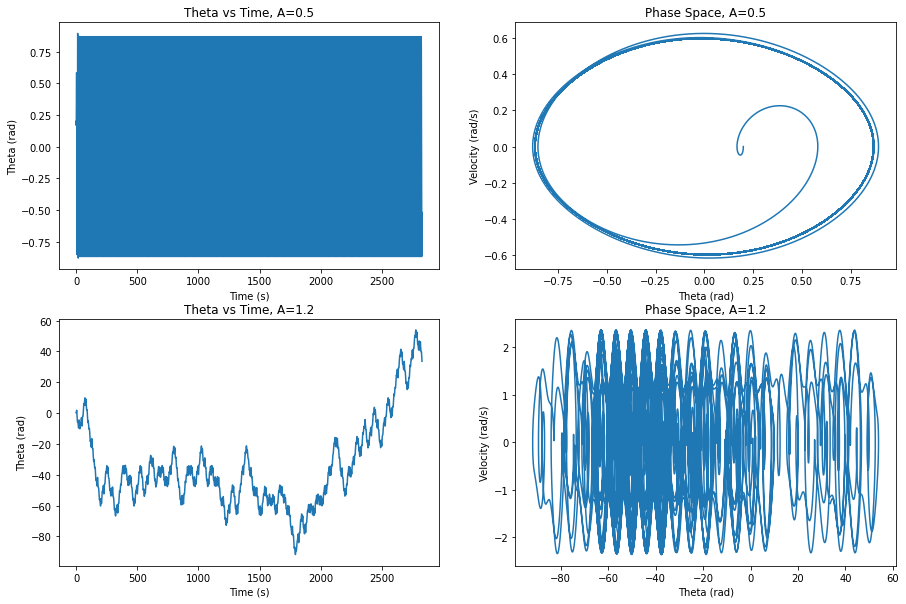

In [12]:
#Constants
m = 1.0
g = 1.0
l = 1.0
nu = 0.5
omega = 2/3

#Initial conditions
theta0 = 0.2
v0 = 0.0

#Time and mesh points
T = 300*2*np.pi/omega
h = 0.001
N = int(T/h)

#Function for the RHS of the ODE
def f(theta, v, t, A):
    return (-g/l)*np.sin(theta) - nu/(m*l**2)*v + A*np.sin(omega*t)

#Euler-Cromer method
def euler_cromer(theta0, v0, A, h, N, T):
    h = T/N
    t = np.zeros(N)
    theta = np.zeros(N)
    v = np.zeros(N)

    theta[0] = theta0
    v[0] = v0

    for i in range(N-1):
        v[i+1] = v[i] + h*f(theta[i], v[i], t[i], A)
        theta[i+1] = theta[i] + h*v[i+1]
        t[i+1] = t[i] + h
    
    return t, theta, v

#Perform calculations for different A values
A = 0.5
t, theta, v = euler_cromer(theta0, v0, A, h, N, T)
# Plot theta vs time
plt.figure(figsize=(15,10))
plt.subplot(2, 2, 1)

plt.plot(t, theta)
plt.xlabel('Time (s)')
plt.ylabel('Theta (rad)')
plt.title(f'Theta vs Time, A={A}')
    
# Plot theta vs v
plt.subplot(2, 2, 2)
plt.plot(theta, v)

plt.xlabel('Theta (rad)')
plt.ylabel('Velocity (rad/s)')
plt.title(f'Phase Space, A={A}')
A = 1.2
t, theta, v = euler_cromer(theta0, v0, A, h, N, T)
# Plot theta vs time
plt.subplot(2, 2, 3)

plt.plot(t, theta)
plt.xlabel('Time (s)')
plt.ylabel('Theta (rad)')
plt.title(f'Theta vs Time, A={A}')
    
# Plot theta vs v
plt.subplot(2, 2, 4)
plt.plot(theta, v)

plt.xlabel('Theta (rad)')
plt.ylabel('Velocity (rad/s)')
plt.title(f'Phase Space, A={A}')

    
plt.show()

Plot 1: $\theta$ vs. time with $A=0.5$

In this plot, we can see the behavior of the pendulum's angular displacement over time for $A=0.5$. We can see that the plot shows an oscillatory behavior with decreasing amplitude as time passes. This is expected behavior for a damped driven pendulum.

Plot 2: Phase space plot of $\theta$ vs. $\omega$ with $A=0.5$

This plot shows the relationship between the pendulum's angular displacement and its angular velocity, also known as the phase space plot. We can see that the plot shows a closed trajectory, indicating that the system is periodic. We can also see that the plot is somewhat elliptical, indicating that the amplitude of the oscillation changes over time, as we saw in plot 1.

Plot 3: $\theta$ vs. time with $A=1.2$

In this plot, we can see the behavior of the pendulum's angular displacement over time for a larger driving force of $A=1.2$. We can see that the plot shows more complex behavior than in plot 1, with multiple amplitude changes and non-sinusoidal oscillations. This is expected behavior for a chaotic system.

Plot 4: Phase space plot of $\theta$ vs. $\omega$ with $A=1.2$

This plot shows the phase space plot for the pendulum with $A=1.2$. We can see that the plot is much more complex than in plot 2, with a much less regular trajectory. This indicates the chaotic behavior of the system, which we saw in plot 3.

Overall, these plots show the behavior of a driven pendulum under different driving forces. We can see that for small driving forces, the behavior is periodic and predictable, while for larger driving forces, the behavior becomes chaotic and unpredictable.




# 1d)

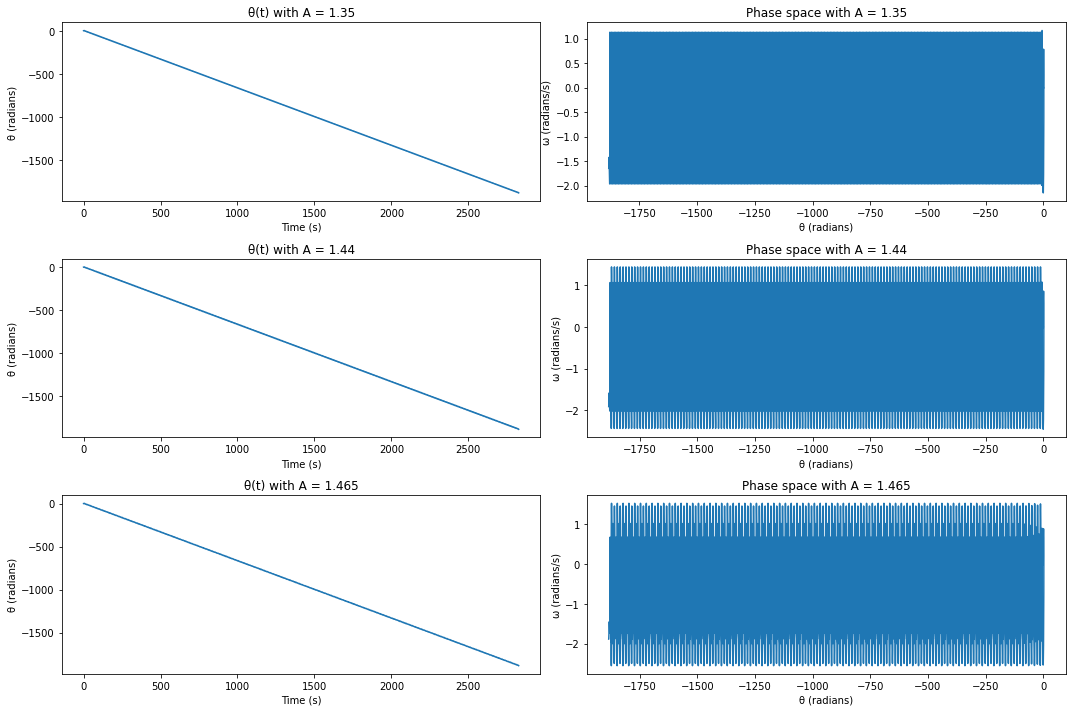

In [18]:
#Constants
m = 1.0
g = 1.0
l = 1.0
nu = 0.5
omega = 2/3

#Initial conditions
theta0 = 0.2
v0 = 0.0

#Time and mesh points
T = 300*2*np.pi/omega
h = 0.001
N = int(T/h)

#Function for the RHS of the ODE
def f(theta, v, t, A):
    return (-g/l)*np.sin(theta) - nu/(m*l**2)*v + A*np.sin(omega*t)

#Euler-Cromer method
def euler_cromer(theta0, v0, A, h, N, T):
    h = T/N
    t = np.zeros(N)
    theta = np.zeros(N)
    v = np.zeros(N)

    theta[0] = theta0
    v[0] = v0

    for i in range(N-1):
        v[i+1] = v[i] + h*f(theta[i], v[i], t[i], A)
        theta[i+1] = theta[i] + h*v[i+1]
        t[i+1] = t[i] + h
    
    return t, theta, v

#Perform calculations for different A values
A3 = 1.35
t, theta, v = euler_cromer(theta0, v0, A3, h, N, T)

plt.figure(figsize=(15,10))
plt.subplot(3,2,1)
plt.plot(t, theta, '-')
plt.title('θ(t) with A = 1.35')
plt.xlabel('Time (s)')
plt.ylabel('θ (radians)')

plt.subplot(3,2,2)
plt.plot(theta, v, '-')
plt.title('Phase space with A = 1.35')
plt.xlabel('θ (radians)')
plt.ylabel('ω (radians/s)')

A4 = 1.44
t, theta, v = euler_cromer(theta0, v0, A4, h, N, T)
plt.subplot(3,2,3)
plt.plot(t, theta, '-')
plt.title('θ(t) with A = 1.44')
plt.xlabel('Time (s)')
plt.ylabel('θ (radians)')

plt.subplot(3,2,4)
plt.plot(theta, v, '-')
plt.title('Phase space with A = 1.44')
plt.xlabel('θ (radians)')
plt.ylabel('ω (radians/s)')

A5 = 1.465
t, theta, v = euler_cromer(theta0, v0, A5, h, N, T)
plt.subplot(3,2,5)
plt.plot(t, theta, '-')
plt.title('θ(t) with A = 1.465')
plt.xlabel('Time (s)')
plt.ylabel('θ (radians)')

plt.subplot(3,2,6)
plt.plot(theta, v, '-')
plt.title('Phase space with A = 1.465')
plt.xlabel('θ (radians)')
plt.ylabel('ω (radians/s)')

plt.tight_layout()
plt.show()

In the plots above, we can see that theta continuously decreases. However, the maximum velocity in each case differs. In the phase space plots, we can see that the maximum velocity that the pendulum attains increases with the amplitude.

# 1e)

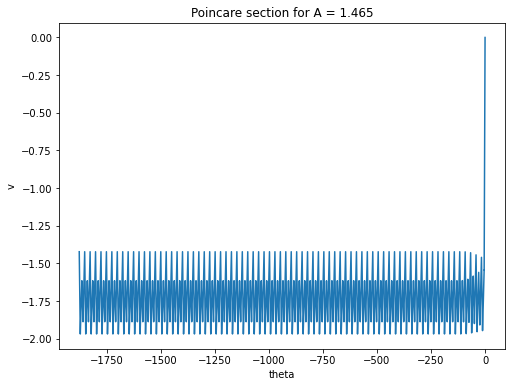

In [25]:
# initialize arrays for storing the Poincare section
theta_poincare = []
v_poincare = []
# loop over the time array
for i in range(N-1):
    
    # check if we are at a drive period
    if np.isclose((omega*t[i]) % (2*np.pi), 0, atol=1e-2).any():
        # append the current values of theta and v to the Poincare section
        theta_poincare.append(theta[i])
        v_poincare.append(v[i])
        
# make Poincare section
theta_poincare = np.array(theta_poincare)
v_poincare = np.array(v_poincare)

# plot Poincare section
plt.figure(figsize=(8,6))
plt.plot(theta_poincare, v_poincare)
plt.xlabel('theta')
plt.ylabel('v')
plt.title('Poincare section for A = 1.465')
plt.show()


### Exercise 2 (20pt), Center-of-Mass and Relative Coordinates and Reference Frames

We define the two-body center-of-mass coordinate and relative coordinate by expressing the trajectories for
$\boldsymbol{r}_1$ and $\boldsymbol{r}_2$ into the center-of-mass coordinate
$\boldsymbol{R}_{\rm cm}$

$$
\boldsymbol{R}_{\rm cm}\equiv\frac{m_1\boldsymbol{r}_1+m_2\boldsymbol{r}_2}{m_1+m_2},
$$

and the relative coordinate

$$
\boldsymbol{r}\equiv\boldsymbol{r}_1-\boldsymbol{r_2}.
$$

Here, we assume the two particles interact only with one another, so $\boldsymbol{F}_{12}=-\boldsymbol{F}_{21}$ (where $\boldsymbol{F}_{ij}$ is the force on $i$ due to $j$.

* 2a (5pt) Show that the equations of motion then become $\ddot{\boldsymbol{R}}_{\rm cm}=0$ and $\mu\ddot{\boldsymbol{r}}=\boldsymbol{F}_{12}$, with the reduced mass $\mu=m_1m_2/(m_1+m_2)$.

The first expression simply states that the center of mass coordinate $\boldsymbol{R}_{\rm cm}$ moves at a fixed velocity. The second expression can be rewritten in terms of the reduced mass $\mu$.

* 2b (5pt) Show that the linear momenta for the center-of-mass $\boldsymbol{P}$ motion and the relative motion $\boldsymbol{q}$ are given by $\boldsymbol{P}=M\dot{\boldsymbol{R}}_{\rm cm}$ with $M=m_1+m_2$ and $\boldsymbol{q}=\mu\dot{\boldsymbol{r}}$.  The linear momentum of the relative motion is defined $\boldsymbol{q} = (m_2\boldsymbol{p}_1-m_1\boldsymbol{p}_2)/(m_1+m_2)$.

* 2c (5pt) Show then the kinetic energy for two objects can then be written as

$$
K=\frac{P^2}{2M}+\frac{q^2}{2\mu}.
$$

* 2d (5pt) Show that the total angular momentum for two-particles in the center-of-mass frame $\boldsymbol{R}=0$, is given by

$$
\boldsymbol{L}=\boldsymbol{r}\times \mu\dot{\boldsymbol{r}}.
$$

### Classical Mechanics Extra Credit Assignment: Scientific Writing and attending Talks

The following gives you an opportunity to earn **five extra credit
points** on each of the remaining homeworks and **ten extra credit points**
on the midterms and finals.  This assignment also covers an aspect of
the scientific process that is not taught in most undergraduate
programs: scientific writing.  Writing scientific reports is how
scientist communicate their results to the rest of the field.  Knowing
how to assemble a well written scientific report will greatly benefit
you in you upper level classes, in graduate school, and in the work
place.

The full information on extra credits is found at <https://github.com/mhjensen/Physics321/blob/master/doc/Homeworks/ExtraCredits/>. There you will also find examples on how to write a scientific article. 
Below you can also find a description on how to gain extra credits by attending scientific talks.

This assignment allows you to gain extra credit points by practicing
your scientific writing.  For each of the remaining homeworks you can
submit the specified section of a scientific report (written about the
numerical aspect of the homework) for five extra credit points on the
assignment.  For the two midterms and the final, submitting a full
scientific report covering the numerical analysis problem will be
worth ten extra points.  For credit the grader must be able to tell
that you put effort into the assignment (i.e. well written, well
formatted, etc.).  If you are unfamiliar with writing scientific
reports, [see the information here](https://github.com/mhjensen/Physics321/blob/master/doc/Homeworks/ExtraCredits/IntroductionScientificWriting.md)

The following table explains what aspect of a scientific report is due
with which homework.  You can submit the assignment in any format you
like, in the same document as your homework, or in a different one.
Remember to cite any external references you use and include a
reference list.  There are no length requirements, but make sure what
you turn in is complete and through.  If you have any questions,
please contact Julie Butler at butler@frib.msu.edu.

<table class="dotable" border="1">
<thead>
<tr><th align="center">  HW/Project </th> <th align="center">Due Date</th> <th align="center">Extra Credit Assignment</th> </tr>
</thead>
<tbody>
<tr><td align="center">   HW 3             </td> <td align="center">   2-8         </td> <td align="center">   Abstract                   </td> </tr>
<tr><td align="center">   HW 4             </td> <td align="center">   2-15        </td> <td align="center">   Introduction               </td> </tr>
<tr><td align="center">   HW 5             </td> <td align="center">   2-22        </td> <td align="center">   Methods                    </td> </tr>
<tr><td align="center">   HW 6             </td> <td align="center">   3-1         </td> <td align="center">   Results and Discussion     </td> </tr>
<tr><td align="center">   **Midterm 1**    </td> <td align="center">   **3-12**    </td> <td align="center">   *Full Written Report*      </td> </tr>
<tr><td align="center">   HW 7             </td> <td align="center">   3-22        </td> <td align="center">   Abstract                   </td> </tr>
<tr><td align="center">   HW 8             </td> <td align="center">   3-29        </td> <td align="center">   Introduction               </td> </tr>
<tr><td align="center">   HW 9             </td> <td align="center">   4-5         </td> <td align="center">   Results and Discussion     </td> </tr>
<tr><td align="center">   **Midterm 2**    </td> <td align="center">   **4-16**    </td> <td align="center">   *Full Written Report*      </td> </tr>
<tr><td align="center">   HW 10            </td> <td align="center">   4-26        </td> <td align="center">   Abstract                   </td> </tr>
<tr><td align="center">   **Final**        </td> <td align="center">   **4-30**    </td> <td align="center">   *Full Written Report*      </td> </tr>
</tbody>
</table>

You can also gain extra credits if you attend scientific talks.
This is described here.

### Integrating Classwork With Research

This opportunity will allow you to earn up to 5 extra credit points on a Homework per week. These points can push you above 100% or help make up for missed exercises.
In order to earn all points you must:

1. Attend an MSU research talk (recommended research oriented Clubs is  provided below)

2. Summarize the talk using at least 150 words

3. Turn in the summary along with your Homework.

Approved talks:
Talks given by researchers through the following clubs:
* Research and Idea Sharing Enterprise (RAISE)​: Meets Wednesday Nights Society for Physics Students (SPS)​: Meets Monday Nights

* Astronomy Club​: Meets Monday Nights

* Facility For Rare Isotope Beam (FRIB) Seminars: ​Occur multiple times a week

If you have any questions please consult Jeremy Rebenstock, rebensto@msu.edu.

All the material on extra credits is at <https://github.com/mhjensen/Physics321/blob/master/doc/Homeworks/ExtraCredits/>.